# Necessary imports

In [2]:
import os
import math
import random
import copy
import time

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import GroupKFold

# Artifacts directories

In [3]:
MODEL_DIR = Path("/kaggle/working/models")
RESULT_DIR = Path("/kaggle/working/results")

MODEL_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)

print(MODEL_DIR)
print(RESULT_DIR)

/kaggle/working/models
/kaggle/working/results


# Experiment configuration

Set the random seed, execution device, dataset dimensions, training parameters, EMA settings, optimizer configuration, and augmentation parameters.

In [ ]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

DATA_DIR = Path("/kaggle/input/competitions/nfl-big-data-bowl-2026-prediction")
TRAIN_DIR = DATA_DIR / "train"

MAX_PLAYERS = 22
INPUT_FRAMES = 20
MAX_OUTPUT_FRAMES = 48

BATCH_SIZE = 64
NUM_WORKERS = 4

EPOCHS = 35
TRAIN_REPEAT_FACTOR = 6
START_VALID_EPOCH = 6

EMA_DECAY = 0.9995
EMA_START_EPOCH = 5

LR = 5e-4
WEIGHT_DECAY = 1e-4
GRAD_MAX_NORM = 200.0

AUX_LOSS_WEIGHT = 0.8

# Augmentation parameters
ANGLE_UNI_RATE = 0.5
FLIP_PROB = 0.5
X_SHIFT_STD = 1.0
Y_SHIFT_STD = 1.5
FRAME_SHIFT_RATE = 0.675
MAX_TIME_SHIFT = 20
LEAST_INPUT_FRAMES = 5

Device: cuda


# Data loading and normalization statistics

Define the input/output columns, weekly data loader, and precomputed normalization statistics for features and targets.

In [ ]:
INPUT_COLUMNS = [
    "game_id", "play_id", "player_to_predict", "nfl_id", "frame_id",
    "play_direction", "absolute_yardline_number",
    "player_name", "player_height", "player_weight", "player_birth_date",
    "player_position", "player_side", "player_role",
    "x", "y", "s", "a", "dir", "o",
    "num_frames_output", "ball_land_x", "ball_land_y",
]

OUTPUT_COLUMNS = ["game_id", "play_id", "nfl_id", "frame_id", "x", "y"]


def load_week(week):
    input_path = TRAIN_DIR / f"input_2023_w{week:02d}.csv"
    output_path = TRAIN_DIR / f"output_2023_w{week:02d}.csv"

    input_df = pd.read_csv(input_path, usecols=INPUT_COLUMNS)
    output_df = pd.read_csv(output_path, usecols=OUTPUT_COLUMNS)

    input_df[["dir", "o"]] = (90.0 - input_df[["dir", "o"]]) % 360.0

    return input_df, output_df


# Precomputed normalization statistics for the 2023 training data.
FEATURE_MEAN = {'x': 60.82776974002471, 'y': 26.66586819309761,
                'ori_sin': -0.028771674664162084, 'ori_cos': -0.0860770011312027,
                'ball_land_x_dx': 4.807716986443858, 'ball_land_y_dy': -0.6598223350763681,
                'receiver_dx': -3.034959448458881, 'receiver_dy': -0.3004955149788581,
                'dir_sin_s': -0.04365514987349996, 'dir_cos_s': 1.7474138934015886,
                'num_frame_output': 11.64147,
                'passer_x': 49.05013399503722, 'passer_y': 26.528289259127966,
                'ball_land_x': 65.33169440307206, 'ball_land_y': 26.221190352646918,
                'player_last_x': 60.82776974002471, 'player_last_y': 26.66586819309761,
                'passer_last_x': 49.05013399503722, 'passer_last_y': 26.528289259127966}

FEATURE_STD = {'x': 23.479941313323085, 'y': 10.00749618625406,
               'ori_sin': 0.543936436139763, 'ori_cos': 0.8342039901959803,
               'ball_land_x_dx': 12.124398080266454, 'ball_land_y_dy': 17.957146201379818,
               'receiver_dx': 7.586012961533925, 'receiver_dy': 14.293949140615915,
               'dir_sin_s': 2.29624100410567, 'dir_cos_s': 2.399019308047086,
               'num_frame_output': 5.3315372,
               'passer_x': 23.15646164494253, 'passer_y': 4.039143779870031,
               'ball_land_x': 24.721183980071213, 'ball_land_y': 15.253264763883333,
               'player_last_x': 23.479941313323085, 'player_last_y': 10.00749618625406,
               'passer_last_x': 23.15646164494253, 'passer_last_y': 4.039143779870031}

TARGET_MEAN = {'dx': 2.4863890033680556, 'dy': -0.0003338034874301969,
               'sx': 0.24357714, 'sy': -0.00259809,
               'ax': -0.00855656, 'ay': 0.00024983}

TARGET_STD = {'dx': 3.9917733048457364, 'dy': 3.728388769750037,
              'sx': 0.30963882, 'sy': 0.42498858,
              'ax': 0.02965129, 'ay': 0.0291162}

TGT_MEAN = np.array([TARGET_MEAN["dx"], TARGET_MEAN["dy"]], dtype=np.float32)
TGT_STD = np.array([TARGET_STD["dx"], TARGET_STD["dy"]], dtype=np.float32)

# Play filtering and identifiers

Define known problematic plays and construct a stable play identifier used during filtering.

In [6]:
TOO_LONG_IDS = {
    "2023091100_3167",
    "2023122100_1450",
}

NO_PASSER_IDS = {
    "2023091001_3216",
    "2023112606_4180",
    "2023121009_3594",
}

EXCLUDE_IDS = (
    TOO_LONG_IDS
    | NO_PASSER_IDS
)


def add_play_id(df):
    df = df.copy()

    df["play_uid"] = (
        df["game_id"].astype(str)
        + "_"
        + df["play_id"].astype(str)
    )

    return df

# Player roles and direction normalization

Encode player roles and transform plays into a common coordinate convention.

In [ ]:
ROLE_MAP = {
    "Defensive Coverage": 0,
    "Targeted Receiver": 1,
    "Passer": 2,
    "Other Route Runner": 3,
}


def sin_deg(x):
    """Compute the sine of an angle specified in degrees."""
    return np.sin(
        np.deg2rad(
            np.asarray(
                x,
                dtype=np.float64,
            )
        )
    )


def cos_deg(x):
    """Compute the cosine of an angle specified in degrees."""
    return np.cos(
        np.deg2rad(
            np.asarray(
                x,
                dtype=np.float64,
            )
        )
    )


def normalize_direction(
    input_play,
    output_play,
):
    """Transform a left-moving play into the common coordinate convention."""
    input_play = input_play.copy()
    output_play = output_play.copy()

    direction = str(
        input_play[
            "play_direction"
        ].iloc[0]
    ).lower()

    if direction != "left":
        return (
            input_play,
            output_play,
        )

    input_play["x"] = (
        120.0
        - input_play["x"].astype(float)
    )

    input_play["y"] = (
        53.3
        - input_play["y"].astype(float)
    )

    input_play["ball_land_x"] = (
        120.0
        - input_play["ball_land_x"].astype(float)
    )

    input_play["ball_land_y"] = (
        53.3
        - input_play["ball_land_y"].astype(float)
    )

    input_play["dir"] = (
        input_play["dir"].astype(float)
        + 180.0
    ) % 360.0

    input_play["o"] = (
        input_play["o"].astype(float)
        + 180.0
    ) % 360.0

    output_play["x"] = (
        120.0
        - output_play["x"].astype(float)
    )

    output_play["y"] = (
        53.3
        - output_play["y"].astype(float)
    )

    return (
        input_play,
        output_play,
    )

# Data augmentation

Define spatial and temporal augmentations, including rotation, vertical flipping, coordinate shifts, and frame shifts.

In [ ]:
def apply_rotation(i_data, o_data, ball_land_xy):
    """Rotate the scene around the player centroid at the last observed frame."""
    if np.random.rand() >= ANGLE_UNI_RATE:
        return i_data, o_data, ball_land_xy

    angle = np.random.uniform(0.0, 2.0 * np.pi)
    c, s = np.cos(angle), np.sin(angle)
    R = np.array([[c, -s], [s, c]], dtype=np.float32)

    center = i_data[:, -1, :2].mean(axis=0)

    def rot(xy):
        """Apply the helper transformation used by the augmentation pipeline."""
        return (xy - center) @ R.T + center

    i_data = i_data.copy()
    o_data = o_data.copy()
    ball_land_xy = ball_land_xy.copy()

    i_data[:, :, 0:2] = rot(i_data[:, :, 0:2])
    o_data[:, :, 0:2] = rot(o_data[:, :, 0:2])
    ball_land_xy[:2] = rot(ball_land_xy[None, :2])[0]


    # Rotate both orientation angles by the same amount.
    angle_deg = np.rad2deg(angle)
    i_data[:, :, 4] = (i_data[:, :, 4] + angle_deg) % 360.0
    i_data[:, :, 5] = (i_data[:, :, 5] + angle_deg) % 360.0

    return i_data, o_data, ball_land_xy


def apply_vertical_flip(i_data, o_data, ball_land_xy):
    """Mirror the scene across the horizontal field axis with probability FLIP_PROB."""
    if np.random.rand() >= FLIP_PROB:
        return i_data, o_data, ball_land_xy

    i_data = i_data.copy()
    o_data = o_data.copy()
    ball_land_xy = ball_land_xy.copy()

    i_data[:, :, 1] = 53.3 - i_data[:, :, 1]
    o_data[:, :, 1] = 53.3 - o_data[:, :, 1]
    ball_land_xy[1] = 53.3 - ball_land_xy[1]

    i_data[:, :, 4] = (360.0 - i_data[:, :, 4]) % 360.0
    i_data[:, :, 5] = (360.0 - i_data[:, :, 5]) % 360.0

    return i_data, o_data, ball_land_xy


def apply_xy_shift(i_data, o_data, ball_land_xy):
    """Apply a random global translation along the x and y axes."""
    i_data = i_data.copy()
    o_data = o_data.copy()
    ball_land_xy = ball_land_xy.copy()

    x_shift = np.random.normal(0.0, X_SHIFT_STD)
    y_shift = np.random.normal(0.0, Y_SHIFT_STD)

    i_data[:, :, 0] += x_shift
    o_data[:, :, 0] += x_shift
    ball_land_xy[0] += x_shift
    i_data[:, :, 1] += y_shift
    o_data[:, :, 1] += y_shift
    ball_land_xy[1] += y_shift

    return i_data, o_data, ball_land_xy


def apply_frame_shift(i_data, o_data):
    """Move a random number of observed frames into the prediction sequence."""
    num_frame_output = o_data.shape[1]

    max_size_from_input = min(MAX_TIME_SHIFT, max(0, i_data.shape[1] - LEAST_INPUT_FRAMES))
    max_size = min(max_size_from_input - 1, MAX_OUTPUT_FRAMES - num_frame_output)

    shift = 0
    if max_size >= 1 and np.random.rand() < FRAME_SHIFT_RATE:
        shift = abs(np.random.normal(0.0, max_size / 3.0))
        shift = int(np.clip(np.round(shift), 0, max_size))

        if shift > 0:
            moved = i_data[:len(o_data), -shift:, :2].astype(o_data.dtype)
            i_data = i_data[:, :-shift]
            o_data = np.concatenate((moved, o_data), axis=1)

    return i_data, o_data, shift

# Play representation

Convert the tabular data for a single play into structured arrays containing player trajectories, roles, and auxiliary spatial information.

In [ ]:
SRC_COLS = ["x", "y", "s", "a", "dir", "o"]


def build_play_dict(input_play, output_play):
    """Convert one play into structured inputs, targets, roles, and auxiliary spatial features."""
    input_play, output_play = normalize_direction(input_play, output_play)

    input_play = input_play.sort_values(["nfl_id", "frame_id"], kind="stable")
    output_play = output_play.sort_values(["nfl_id", "frame_id"], kind="stable")

    i_info = (
        input_play[["nfl_id", "player_role", "player_to_predict"]]
        .drop_duplicates()
        .reset_index(drop=True)
    )

    i_nfl_ids = input_play["nfl_id"].drop_duplicates().to_numpy()
    o_nfl_ids = output_play["nfl_id"].drop_duplicates().to_numpy()

    # Keep players with prediction targets first
    o_set = set(o_nfl_ids.tolist())
    order = [i for i, p in enumerate(i_nfl_ids) if p in o_set]
    order += [i for i, p in enumerate(i_nfl_ids) if p not in o_set]

    num_player_input = len(i_nfl_ids)
    num_frame_input = len(input_play) // num_player_input
    num_frame_output = int(output_play["frame_id"].max())
    num_player_output = len(o_nfl_ids)

    i_data = input_play[SRC_COLS].to_numpy(dtype=np.float32).reshape(
        num_player_input, num_frame_input, len(SRC_COLS)
    )
    o_data = output_play[["x", "y"]].to_numpy(dtype=np.float32).reshape(
        num_player_output, num_frame_output, 2
    )

    i_data = i_data[order]
    i_info = i_info.iloc[order].reset_index(drop=True)

    receiver_xy = input_play.loc[
        input_play["player_role"] == "Targeted Receiver", ["x", "y"]
    ].to_numpy(dtype=np.float32)
    if len(receiver_xy) == 0:
        receiver_xy = input_play.loc[
            input_play["player_role"] == "Passer", ["x", "y"]
        ].to_numpy(dtype=np.float32)

    passer_xy = input_play.loc[
        input_play["player_role"] == "Passer", ["x", "y"]
    ].to_numpy(dtype=np.float32)

    ball_land_xy = input_play.iloc[0][["ball_land_x", "ball_land_y"]].to_numpy(dtype=np.float32)

    return {
        "i_data": i_data,
        "o_data": o_data,
        "i_info": i_info,
        "receiver_xy": receiver_xy,
        "passer_xy": passer_xy,
        "ball_land_xy": ball_land_xy,
        "game_id": int(input_play["game_id"].iloc[0]),
        "play_id": int(input_play["play_id"].iloc[0]),
    }

# Weekly play construction

Load a week of data, remove excluded or incomplete plays, and build structured play objects.

In [ ]:
def build_week_plays(week):
    """Load one week, filter invalid plays, and build structured play objects."""
    input_df, output_df = load_week(week)

    input_df = add_play_id(input_df)
    output_df = add_play_id(output_df)

    input_df = input_df[~input_df["play_uid"].isin(EXCLUDE_IDS)]
    output_df = output_df[~output_df["play_uid"].isin(EXCLUDE_IDS)]

    input_groups = input_df.groupby(["game_id", "play_id"], sort=False)
    output_groups = output_df.groupby(["game_id", "play_id"], sort=False)

    plays = []

    for key, input_play in input_groups:
        if key not in output_groups.groups:
            continue

        if not (input_play["player_role"] == "Passer").any():
            continue

        output_play = output_groups.get_group(key)
        plays.append(build_play_dict(input_play, output_play))

    return plays

# Data structure check

Inspect the number of plays, array shapes, and data types produced by the preprocessing pipeline.

In [ ]:
plays_w01 = build_week_plays(week=1)

print("Plays:", len(plays_w01))

play = plays_w01[0]

for key, value in play.items():
    if hasattr(value, "shape"):
        dtype = value.dtype if hasattr(value, "dtype") else value.dtypes
        print(key, value.shape, dtype)
    else:
        print(key, value)
        
"""
Inspect the distribution of future x/y displacements 
relative to the last observed player position.
"""  

deltas = []

for play in plays_w01[:200]:
    o = play["o_data"]
    last = play["i_data"][: len(o), -1, :2]
    deltas.append((o - last[:, None, :]).reshape(-1, 2))

deltas = np.concatenate(deltas, axis=0)

print(pd.DataFrame(deltas, columns=["dx", "dy"]).describe())

Plays: 817
i_data (9, 26, 6) float32
o_data (3, 21, 2) float32
i_info (9, 3) nfl_id                int64
player_role          object
player_to_predict      bool
dtype: object
receiver_xy (26, 2) float32
passer_xy (26, 2) float32
ball_land_xy (2,) float32
game_id 2023090700
play_id 101


In [ ]:
"""
Verify that the calculated target displacements do not contain obviously invalid extreme values
"""

assert np.max(np.abs(deltas)) < 1000

# Dataset and feature construction

Build dynamic and static features, target tensors, masks, normalization, and padding required by the neural network.

In [ ]:
DYNAMIC_FEATURES = ["x", "y", "ori_sin", "ori_cos",
                    "ball_land_x_dx", "ball_land_y_dy",
                    "receiver_dx", "receiver_dy",
                    "dir_sin_s", "dir_cos_s"]

PLAYER_LAST_XY_MEAN = np.array([FEATURE_MEAN["player_last_x"], FEATURE_MEAN["player_last_y"]], dtype=np.float32)
PLAYER_LAST_XY_STD = np.array([FEATURE_STD["player_last_x"], FEATURE_STD["player_last_y"]], dtype=np.float32)
PASSER_LAST_XY_MEAN = np.array([FEATURE_MEAN["passer_last_x"], FEATURE_MEAN["passer_last_y"]], dtype=np.float32)
PASSER_LAST_XY_STD = np.array([FEATURE_STD["passer_last_x"], FEATURE_STD["passer_last_y"]], dtype=np.float32)
BALL_LAND_XY_MEAN = np.array([FEATURE_MEAN["ball_land_x"], FEATURE_MEAN["ball_land_y"]], dtype=np.float32)
BALL_LAND_XY_STD = np.array([FEATURE_STD["ball_land_x"], FEATURE_STD["ball_land_y"]], dtype=np.float32)


class NFLDataset(Dataset):
    """Neural-network component used by the trajectory prediction model."""
    def __init__(self, plays, is_train=False, repeat_factor=1):
        """Initialize the module and its parameters."""
        self.plays = plays
        self.is_train = is_train
        self.repeat_factor = repeat_factor

        self.feat_mean = np.array([FEATURE_MEAN[n] for n in DYNAMIC_FEATURES], dtype=np.float32)
        self.feat_std = np.array([FEATURE_STD[n] for n in DYNAMIC_FEATURES], dtype=np.float32)
        self.target_mean = np.array([TARGET_MEAN[n] for n in ("dx", "dy")], dtype=np.float32)
        self.target_std = np.array([TARGET_STD[n] for n in ("dx", "dy")], dtype=np.float32)
        self.target_sa_mean = np.array([TARGET_MEAN[n] for n in ("sx", "sy", "ax", "ay")], dtype=np.float32)
        self.target_sa_std = np.array([TARGET_STD[n] for n in ("sx", "sy", "ax", "ay")], dtype=np.float32)

    def __len__(self):
        """Return the number of available dataset samples."""
        return len(self.plays) * self.repeat_factor

    def __getitem__(self, i):
        """Build one training example from a selected play."""
        i = i % len(self.plays)
        play = self.plays[i]

        i_data = play["i_data"].copy()
        o_data = play["o_data"].copy()
        ball_land_xy = play["ball_land_xy"].astype(np.float32).copy()
        roles = play["i_info"]["player_role"].to_numpy()

        receiver_idx = int(np.where(roles == "Targeted Receiver")[0][0])
        passer_idx = int(np.where(roles == "Passer")[0][0])

        frame_shift = 0
        if self.is_train:
            i_data, o_data, frame_shift = apply_frame_shift(i_data, o_data)
            i_data, o_data, ball_land_xy = apply_rotation(i_data, o_data, ball_land_xy)
            i_data, o_data, ball_land_xy = apply_vertical_flip(i_data, o_data, ball_land_xy)
            i_data, o_data, ball_land_xy = apply_xy_shift(i_data, o_data, ball_land_xy)

        receiver_xy = i_data[receiver_idx][:, :2]
        passer_xy = i_data[passer_idx][:, :2]

        num_player_input, num_frame_input, _ = i_data.shape
        num_player_output, num_frame_output, _ = o_data.shape

        # Dynamic features: (players, time, 10).
        ext = np.zeros((num_player_input, num_frame_input, 10), dtype=np.float32)
        ext[:, :, 0] = i_data[:, :, 0]                                       # x
        ext[:, :, 1] = i_data[:, :, 1]                                       # y
        ext[:, :, 2] = np.sin(np.deg2rad(i_data[:, :, 5]))                   # ori_sin
        ext[:, :, 3] = np.cos(np.deg2rad(i_data[:, :, 5]))                   # ori_cos
        ext[:, :, 4] = ball_land_xy[0] - i_data[:, :, 0]                     # ball_land_x_dx
        ext[:, :, 5] = ball_land_xy[1] - i_data[:, :, 1]                     # ball_land_y_dy
        ext[:, :, 6] = receiver_xy[None, :, 0] - i_data[:, :, 0]             # receiver_dx
        ext[:, :, 7] = receiver_xy[None, :, 1] - i_data[:, :, 1]             # receiver_dy
        ext[:, :, 8] = np.sin(np.deg2rad(i_data[:, :, 4])) * i_data[:, :, 2] # dir_sin_s
        ext[:, :, 9] = np.cos(np.deg2rad(i_data[:, :, 4])) * i_data[:, :, 2] # dir_cos_s

        # Keep the most recent input frames.
        ext = ext[:, -INPUT_FRAMES:]

        # Target displacements.
        last_xy = i_data[:num_player_output, -1, :2].astype(np.float32).copy()  # (P_out, 2)
        target_xy = o_data - last_xy[:, None, :]                                # deltas

        # Auxiliary velocity and acceleration targets.
        last_two = i_data[:num_player_output, -2:, :2].astype(np.float32)
        v = np.diff(np.concatenate((last_two, o_data), axis=1), axis=1)   # (P_out, L+1, 2)
        a = np.diff(v, axis=1)                                            # (P_out, L, 2)
        v = v[:, 1:]                                                      # (P_out, L, 2)
        target_sa = np.concatenate((v, a), axis=2).astype(np.float32)     # (P_out, L, 4)

        # Normalize features and targets.
        ext = (ext - self.feat_mean) / self.feat_std
        target_xy = (target_xy - self.target_mean) / self.target_std
        target_sa = (target_sa - self.target_sa_mean) / self.target_sa_std

        ext = np.nan_to_num(ext)
        target_xy = np.nan_to_num(target_xy)
        target_sa = np.nan_to_num(target_sa)

        # Pad tensors to fixed dimensions.
        pad_in_players = MAX_PLAYERS - num_player_input
        pad_out_players = MAX_PLAYERS - num_player_output
        pad_frames_in = INPUT_FRAMES - ext.shape[1]
        pad_frames_out = MAX_OUTPUT_FRAMES - num_frame_output

        ext = np.pad(ext, ((0, pad_in_players), (pad_frames_in, 0), (0, 0)))
        target_xy = np.pad(target_xy, ((0, pad_out_players), (0, pad_frames_out), (0, 0)))
        target_sa = np.pad(target_sa, ((0, pad_out_players), (0, pad_frames_out), (0, 0)))

        # Static features: (22, 12).
        role_onehot = np.identity(4, dtype=np.float32)[[ROLE_MAP[r] for r in roles]]

        static = np.zeros((MAX_PLAYERS, 12), dtype=np.float32)
        static[:num_player_input, :4] = role_onehot
        static[:, 4] = (num_frame_output - FEATURE_MEAN["num_frame_output"]) / FEATURE_STD["num_frame_output"]
        static[:, 5] = (frame_shift - 3.0) / 3.0
        static[:, 6:8] = (passer_xy[-1] - PASSER_LAST_XY_MEAN) / PASSER_LAST_XY_STD
        static[:, 8:10] = (ball_land_xy - BALL_LAND_XY_MEAN) / BALL_LAND_XY_STD
        static[:num_player_input, 10:12] = (
            (i_data[:, -1, :2] - PLAYER_LAST_XY_MEAN) / PLAYER_LAST_XY_STD
        )

        # Target mask.
        target_mask = np.zeros((MAX_PLAYERS, MAX_OUTPUT_FRAMES), dtype=np.float32)
        target_mask[:num_player_output, :num_frame_output] = 1.0

        # Padded last observed positions used to recover absolute coordinates.
        last_xy_padded = np.zeros((2, MAX_PLAYERS), dtype=np.float32)
        last_xy_padded[:, :num_player_output] = last_xy.T

        return {
            "dynamic": torch.tensor(ext.transpose(2, 0, 1)).float(),          
            "static": torch.tensor(static).float(),                           
            "target_xy": torch.tensor(target_xy.transpose(2, 0, 1)).float(),  
            "target_sa": torch.tensor(target_sa.transpose(2, 0, 1)).float(),  
            "target_mask": torch.tensor(target_mask).float(),                 
            "last_xy": torch.tensor(last_xy_padded).float(),                  
            "num_frame_output": torch.tensor(num_frame_output).long(),
            "num_player_output": torch.tensor(num_player_output).long(),
            "num_player_input": torch.tensor(num_player_input).long(),
        }

# Model architecture

Define the convolutional blocks, Transformer encoder, prediction head, and complete trajectory model.

In [ ]:
class Block(nn.Module):
    """Neural-network component used by the trajectory prediction model."""
    def __init__(self, dim, kernel_size=3, groups=1, padding=0, actf=nn.SiLU()):
        """Initialize the module and its parameters."""
        super().__init__()

        self.block = nn.Sequential(
            nn.BatchNorm1d(dim),
            actf,
            nn.Conv1d(dim, dim, kernel_size=kernel_size, groups=groups, padding=padding, bias=False),
            nn.BatchNorm1d(dim),
            actf,
            nn.Conv1d(dim, dim, kernel_size=kernel_size, groups=groups, padding=padding, bias=False),
        )

    def forward(self, x):
        """Run a forward pass and return main and auxiliary prediction parameters."""
        return self.block(x)


class ResBlock(nn.Module):
    """Neural-network component used by the trajectory prediction model."""
    def __init__(self, dim, kernel_size=3, groups=1, actf=nn.SiLU()):
        """Initialize the module and its parameters."""
        super().__init__()

        padding = (kernel_size - 1) // 2
        self.block = Block(dim=dim, kernel_size=kernel_size, padding=padding, groups=groups, actf=actf)

    def forward(self, x):
        """Run a forward pass and return main and auxiliary prediction parameters."""
        return x + self.block(x)


class SequenceStem(nn.Module):
    """Apply a depthwise convolution followed by three residual blocks."""

    def __init__(self, input_dim, nbai, kernel_size=3):
        """Initialize the module and its parameters."""
        super().__init__()

        dim = input_dim * nbai

        self.stem = nn.Conv1d(
            input_dim, dim,
            kernel_size=kernel_size,
            groups=input_dim,
            bias=False,
        )

        self.blocks = nn.ModuleList([
            Block(dim, kernel_size, padding=0, groups=input_dim),
            Block(dim, kernel_size, padding=0, groups=input_dim),
            Block(dim, kernel_size, padding=0, groups=input_dim // 2),
        ])

        self.crop = (kernel_size - 1) * 2

    def forward(self, x):
        """Run a forward pass and return main and auxiliary prediction parameters."""
        x = self.stem(x)

        for block in self.blocks:
            x = x[:, :, self.crop:] + block(x)

        return x


class MyTransformerEncoderLayer(nn.Module):
    """Pre-norm Transformer encoder layer with a SwiGLU feed-forward network."""

    def __init__(self, d_model, nhead, dim_feedforward=2048, dropout=0.1, batch_first=True):
        """Initialize the module and its parameters."""
        super().__init__()

        self.self_attn = nn.MultiheadAttention(
            d_model, nhead, dropout=dropout, batch_first=batch_first,
        )

        self.linear1_w1 = nn.Linear(d_model, dim_feedforward)
        self.linear1_w2 = nn.Linear(d_model, dim_feedforward)
        self.linear2 = nn.Linear(dim_feedforward, d_model)

        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

        self.dropout = nn.Dropout(dropout)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)

    def _ffn_swiglu(self, x):
        """Apply the SwiGLU feed-forward transformation."""
        a = self.linear1_w1(x)
        b = F.silu(self.linear1_w2(x))
        return self.linear2(self.dropout(a * b))

    def forward(self, src, src_key_padding_mask=None):
        """Run a forward pass and return main and auxiliary prediction parameters."""
        src2 = self.norm1(src)

        attn_out, _ = self.self_attn(
            src2, src2, src2,
            key_padding_mask=src_key_padding_mask,
            need_weights=False,
        )

        src = src + self.dropout1(attn_out)

        src2 = self.norm2(src)
        src2 = self._ffn_swiglu(src2)
        src = src + self.dropout2(src2)

        return src


class MyTransformerEncoder(nn.Module):
    """Neural-network component used by the trajectory prediction model."""
    def __init__(self, layer, num_layers):
        """Initialize the module and its parameters."""
        super().__init__()
        self.layers = nn.ModuleList([copy.deepcopy(layer) for _ in range(num_layers)])

    def forward(self, x, src_key_padding_mask=None):
        """Run a forward pass and return main and auxiliary prediction parameters."""
        for layer in self.layers:
            x = layer(x, src_key_padding_mask=src_key_padding_mask)
        return x


class Head(nn.Module):
    """Neural-network component used by the trajectory prediction model."""
    def __init__(self, dim2, aux_target_dim, kernel_size=3):
        """Initialize the module and its parameters."""
        super().__init__()

        self.dim2 = dim2
        self.aux_target_dim = aux_target_dim

        self.model = nn.Sequential(
            ResBlock(dim2, kernel_size=kernel_size),
            ResBlock(dim2, kernel_size=kernel_size),
        )
        self.head_mu = nn.Conv1d(dim2, 2, kernel_size=1)
        self.head_var = nn.Conv1d(dim2, 2, kernel_size=1)
        self.head_aux_mu = nn.Conv1d(dim2, aux_target_dim, kernel_size=1)
        self.head_aux_var = nn.Conv1d(dim2, aux_target_dim, kernel_size=1)

    def _reshape_permute(self, x, bsize, num_player):
        """Reshape convolutional output to batch × channels × players × time."""
        _, C, L = x.shape
        return torch.permute(torch.reshape(x, (bsize, num_player, C, L)), (0, 2, 1, 3))

    def forward(self, z, bsize, num_player):
        """Run a forward pass and return main and auxiliary prediction parameters."""
        z = self.model(z)

        pred_m = self._reshape_permute(self.head_mu(z), bsize, num_player)
        pred_v = self._reshape_permute(self.head_var(z), bsize, num_player)
        aux_m = self._reshape_permute(self.head_aux_mu(z), bsize, num_player)
        aux_v = self._reshape_permute(self.head_aux_var(z), bsize, num_player)

        return pred_m, pred_v, aux_m, aux_v


class Model(nn.Module):
    """Neural-network component used by the trajectory prediction model."""
    def __init__(
        self,
        input_dim=10,
        output_sequence_size=48,
        dim1=256,
        dim2=32,
        input_dim_multiplier=64,
        tfm_nhead=8,
        dim_feedforward=1024,
        tfm_dropout=0.05,
        num_layers=3,
        min_var=0.001,
        aux_target_dim=4,
        static_feature_dim=12,
    ):
        """Initialize the module and its parameters."""
        super().__init__()

        self.dim1 = dim1
        self.dim2 = dim2
        self.output_sequence_size = output_sequence_size
        self.min_var = min_var

        dim0 = input_dim * input_dim_multiplier + input_dim_multiplier

        self.sequence_stem = SequenceStem(input_dim, input_dim_multiplier)
        self.feature_stem = nn.Sequential(
            nn.Conv1d(static_feature_dim, input_dim_multiplier, kernel_size=1, bias=False),
            nn.BatchNorm1d(input_dim_multiplier),
            nn.SiLU(),
        )

        self.merge_layer = nn.Sequential(
            nn.Conv1d(dim0, dim1, kernel_size=1, bias=False),
            nn.BatchNorm1d(dim1),
            ResBlock(dim1, kernel_size=1),
            ResBlock(dim1, kernel_size=1),
            nn.BatchNorm1d(dim1),
        )

        encoder_layer = MyTransformerEncoderLayer(
            d_model=dim1, nhead=tfm_nhead,
            dim_feedforward=dim_feedforward,
            dropout=tfm_dropout, batch_first=True,
        )
        self.encoder = MyTransformerEncoder(encoder_layer, num_layers=num_layers)

        self.pred_sequence_layer = nn.Conv1d(dim1, output_sequence_size * dim2, kernel_size=1)
        self.head = Head(dim2, aux_target_dim)

    def forward(self, dynamic, static, num_player_input):
        """Run a forward pass and return main and auxiliary prediction parameters."""
        bsize, c, num_player, l = dynamic.shape

        x_dynamic = torch.permute(dynamic, (0, 2, 1, 3)).reshape(bsize * num_player, c, l)
        x_static = static.reshape(bsize * num_player, -1, 1)

        x_dynamic = self.sequence_stem(x_dynamic)
        x_static = self.feature_stem(x_static)

        x_dynamic = x_dynamic[:, :, -1:]
        x = torch.cat((x_dynamic, x_static), dim=1)
        x = self.merge_layer(x)
        x = x.reshape(bsize, num_player, self.dim1)

        key_padding_mask = (
            torch.arange(num_player, device=x.device).expand(bsize, num_player)
            >= num_player_input.to(x.device).unsqueeze(1)
        )

        x = self.encoder(x, src_key_padding_mask=key_padding_mask)
        x = x.reshape(bsize * num_player, self.dim1, 1)

        x = self.pred_sequence_layer(x)
        z = x.reshape(-1, self.dim2, self.output_sequence_size)

        pred_m, pred_v, aux_m, aux_v = self.head(z, bsize, num_player)

        return {"main_mean": pred_m, "main_var": pred_v, "aux_mean": aux_m, "aux_var": aux_v}

# Loss function

Use Gaussian negative log-likelihood for the main coordinate prediction and an auxiliary velocity/acceleration prediction task.

In [ ]:
MIN_VAR = 0.001


def gaussian_nll(mean, target, variance):
    """Compute Gaussian negative log-likelihood for the predicted mean and variance."""
    return 0.5 * (torch.log(variance) + (target - mean) ** 2 / variance)


def compute_loss(output, target_xy, target_sa, target_mask):
    """Combine the main Gaussian NLL with the auxiliary velocity/acceleration loss."""
    m = target_mask.unsqueeze(1)
    denom = target_mask.sum().clamp_min(1.0) * 2.0

    main_var = F.softplus(output["main_var"]) + MIN_VAR
    pred_loss = gaussian_nll(output["main_mean"], target_xy, main_var)
    pred_loss = (pred_loss * m).sum() / denom

    aux_var = F.softplus(output["aux_var"]) + MIN_VAR
    aux_loss = gaussian_nll(output["aux_mean"], target_sa, aux_var)
    aux_loss = aux_loss * (2.0 / aux_loss.shape[1])
    aux_loss = (aux_loss * m).sum() / denom

    return (1.0 - AUX_LOSS_WEIGHT) * pred_loss + AUX_LOSS_WEIGHT * aux_loss

# Full dataset preparation

Process weeks 1–18 and combine the available plays into a single collection.

In [17]:
all_plays = []

for week in range(1, 19):
    week_plays = build_week_plays(week)
    all_plays.extend(week_plays)
    print(f"Week {week:02d}: {len(week_plays)}")

print("Total plays:", len(all_plays))

Week 01: 817
Week 02: 850
Week 03: 904
Week 04: 779
Week 05: 742
Week 06: 793
Week 07: 693
Week 08: 827
Week 09: 711
Week 10: 721
Week 11: 707
Week 12: 853
Week 13: 666
Week 14: 795
Week 15: 791
Week 16: 895
Week 17: 809
Week 18: 750
Total plays: 14103


# GroupKFold split

Split the data by game_id so that plays from the same game cannot appear in both training and validation.

In [18]:
groups = np.array([play["game_id"] for play in all_plays])

gkf = GroupKFold(n_splits=5)

train_idx, valid_idx = next(gkf.split(all_plays, groups=groups))

train_plays = [all_plays[i] for i in train_idx]
valid_plays = [all_plays[i] for i in valid_idx]

print("Train plays:", len(train_plays))
print("Valid plays:", len(valid_plays))
print("Train games:", len(np.unique(groups[train_idx])))
print("Valid games:", len(np.unique(groups[valid_idx])))

Train plays: 11294
Valid plays: 2809
Train games: 218
Valid games: 54


# DataLoaders

Create training and validation datasets and DataLoaders, including training-set repetition and worker seeding.

In [ ]:
def seed_worker(worker_id):
    """Seed NumPy and Python random generators for a DataLoader worker."""
    worker_seed = torch.initial_seed() % 2 ** 32
    np.random.seed(worker_seed)
    random.seed(worker_seed)


train_dataset = NFLDataset(train_plays, is_train=True, repeat_factor=TRAIN_REPEAT_FACTOR)
valid_dataset = NFLDataset(valid_plays, is_train=False)

generator = torch.Generator()
generator.manual_seed(SEED)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    drop_last=True,
    pin_memory=True,
    persistent_workers=True,
    worker_init_fn=seed_worker,
    generator=generator,
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

print("Train samples (с repeat):", len(train_dataset))
print("Train batches:", len(train_loader))
print("Valid batches:", len(valid_loader))

Train samples (с repeat): 67764
Train batches: 1058
Valid batches: 44


# Model and optimizer initialization

Instantiate the trajectory model and configure the RAdam optimizer.

In [ ]:
model = Model(
    input_dim=len(DYNAMIC_FEATURES),
    output_sequence_size=MAX_OUTPUT_FRAMES,
).to(DEVICE)


optimizer = torch.optim.RAdam(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY,
    decoupled_weight_decay=True,
)

print("Parameters:", sum(p.numel() for p in model.parameters()))

Parameters: 5005452


# Forward-pass check

Run one batch through the model and verify the shapes and types of its outputs.

In [21]:
batch = next(iter(train_loader))

with torch.no_grad():
    output = model(
        batch["dynamic"].to(DEVICE),
        batch["static"].to(DEVICE),
        batch["num_player_input"].to(DEVICE),
    )

for key, value in output.items():
    print(key, tuple(value.shape), value.dtype)

print("target_xy:", tuple(batch["target_xy"].shape))
print("target_mask:", tuple(batch["target_mask"].shape))

main_mean (64, 2, 22, 48) torch.float32
main_var (64, 2, 22, 48) torch.float32
aux_mean (64, 4, 22, 48) torch.float32
aux_var (64, 4, 22, 48) torch.float32
target_xy: (64, 2, 22, 48)
target_mask: (64, 22, 48)


# EMA and model training

Maintain an exponential moving average of the model weights, train for the configured number of epochs, evaluate on validation data, and save the best checkpoint.

In [ ]:
class ModelEMA:
    """Maintain an exponential moving-average copy of the model weights."""

    def __init__(self, model, decay):
        self.decay = decay
        self.module = copy.deepcopy(model).eval()
        for p in self.module.parameters():
            p.requires_grad_(False)

    @torch.no_grad()
    def update(self, model):
        """Update the exponential moving average of the model parameters."""
        msd = model.state_dict()
        for k, v in self.module.state_dict().items():
            if v.dtype.is_floating_point:
                v.mul_(self.decay).add_(msd[k].detach(), alpha=1.0 - self.decay)
            else:
                v.copy_(msd[k])


@torch.no_grad()
def evaluate(model, loader):
    """Evaluate validation NLL and RMSE in absolute coordinates."""
    model.eval()
    val_loss, n_val = 0.0, 0.0
    sq_err, n_pts = 0.0, 0.0

    for batch in loader:
        dynamic = batch["dynamic"].to(DEVICE)
        static = batch["static"].to(DEVICE)
        npi = batch["num_player_input"].to(DEVICE)
        target_xy = batch["target_xy"].to(DEVICE)
        target_sa = batch["target_sa"].to(DEVICE)
        target_mask = batch["target_mask"].to(DEVICE)

        output = model(dynamic, static, npi)
        loss = compute_loss(output, target_xy, target_sa, target_mask)

        num = batch["num_frame_output"].sum().item() * 2
        val_loss += loss.item() * num
        n_val += num

        pred = output["main_mean"].cpu().numpy()      # (B, 2, P, L)
        tgt = target_xy.cpu().numpy()
        mask = target_mask.cpu().numpy()              # (B, P, L)
        last_xy = batch["last_xy"].numpy()            # (B, 2, P)

        pred_xy = pred * TGT_STD[None, :, None, None] + TGT_MEAN[None, :, None, None] + last_xy[:, :, :, None]  # <--- ИСПРАВЛЕНО
        true_xy = tgt * TGT_STD[None, :, None, None] + TGT_MEAN[None, :, None, None] + last_xy[:, :, :, None]   # <--- ИСПРАВЛЕНО

        m = mask[:, None].astype(bool)                # (B, 1, P, L)
        err2 = ((pred_xy - true_xy) ** 2) * m

        sq_err += err2.sum()
        n_pts += m.sum() * 2

    return val_loss / n_val, float(np.sqrt(sq_err / n_pts))


scaler = torch.amp.GradScaler("cuda", init_scale=1024.0)
history = []
best_score = float("inf")
ema = None

for epoch in range(1, EPOCHS + 1):
    start = time.time()

    if epoch == EMA_START_EPOCH:
        ema = ModelEMA(model, EMA_DECAY)
        print("EMA включён")

    model.train()
    train_loss, n_tr = 0.0, 0.0

    for batch in train_loader:
        dynamic = batch["dynamic"].to(DEVICE, non_blocking=True)
        static = batch["static"].to(DEVICE, non_blocking=True)
        npi = batch["num_player_input"].to(DEVICE, non_blocking=True)
        target_xy = batch["target_xy"].to(DEVICE, non_blocking=True)
        target_sa = batch["target_sa"].to(DEVICE, non_blocking=True)
        target_mask = batch["target_mask"].to(DEVICE, non_blocking=True)

        optimizer.zero_grad()

        with torch.autocast(device_type="cuda", dtype=torch.float16):
            output = model(dynamic, static, npi)
            loss = compute_loss(output, target_xy, target_sa, target_mask)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_MAX_NORM)
        scaler.step(optimizer)
        scaler.update()

        if ema is not None:
            ema.update(model)

        num = batch["num_frame_output"].sum().item() * 2
        train_loss += loss.item() * num
        n_tr += num

    train_loss /= n_tr

    val_loss, val_score = np.nan, np.nan
    if epoch >= START_VALID_EPOCH:
        eval_model = ema.module if ema is not None else model
        val_loss, val_score = evaluate(eval_model, valid_loader)
        if val_score < best_score:
            best_score = val_score
            torch.save(eval_model.state_dict(), MODEL_DIR / "nfl_1st_place_best.pt")

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "val_score": val_score,
    })

    print(
        f"Epoch {epoch:03d}/{EPOCHS} | train={train_loss:.4f} "
        f"| val={val_loss:.4f} | CV-RMSE={val_score:.4f} | {time.time() - start:.0f}s"
    )

print(f"\nBest CV-RMSE: {best_score:.4f}")
history = pd.DataFrame(history)

Epoch 001/35 | train=-0.4801 | val=nan | CV-RMSE=nan | 108s
Epoch 002/35 | train=-0.7499 | val=nan | CV-RMSE=nan | 109s
Epoch 003/35 | train=-0.8352 | val=nan | CV-RMSE=nan | 109s
Epoch 004/35 | train=-0.8913 | val=nan | CV-RMSE=nan | 109s
EMA включён
Epoch 005/35 | train=-0.9006 | val=nan | CV-RMSE=nan | 113s
Epoch 006/35 | train=-0.9177 | val=-1.1629 | CV-RMSE=0.5200 | 123s
Epoch 007/35 | train=-0.9597 | val=-1.1848 | CV-RMSE=0.5125 | 122s
Epoch 008/35 | train=-0.9810 | val=-1.2015 | CV-RMSE=0.5062 | 122s
Epoch 009/35 | train=-0.9908 | val=-1.2098 | CV-RMSE=0.5005 | 123s
Epoch 010/35 | train=-1.0048 | val=-1.2222 | CV-RMSE=0.4928 | 123s
Epoch 011/35 | train=-1.0024 | val=-1.2287 | CV-RMSE=0.4908 | 123s
Epoch 012/35 | train=-1.0204 | val=-1.2401 | CV-RMSE=0.4864 | 123s
Epoch 013/35 | train=-1.0348 | val=-1.2530 | CV-RMSE=0.4809 | 123s
Epoch 014/35 | train=-1.0437 | val=-1.2650 | CV-RMSE=0.4775 | 123s
Epoch 015/35 | train=-1.0520 | val=-1.2747 | CV-RMSE=0.4737 | 123s
Epoch 016/35 | tra

# Model artifact

Save the model weights together with the configuration and normalization statistics, then verify that the artifact can reconstruct the model.

In [ ]:
import pickle

torch.save(model.state_dict(), MODEL_DIR / "nfl_1st_place_best.pt")

# Save the model configuration.
CONFIG = {
    "input_dim": len(DYNAMIC_FEATURES),
    "output_sequence_size": MAX_OUTPUT_FRAMES,
    "dim1": 256, "dim2": 32,
    "input_dim_multiplier": 64,
    "tfm_nhead": 8, "dim_feedforward": 1024,
    "tfm_dropout": 0.05, "num_layers": 3,
    "min_var": 0.001, "aux_target_dim": 4,
    "static_feature_dim": 12,
}

ARTIFACT_PATH = MODEL_DIR / "nfl_1st_place_model.pkl"
with open(ARTIFACT_PATH, "wb") as f:
    pickle.dump(
        {
            "state_dict": model.state_dict(),
            "config": CONFIG,
            "dynamic_features": DYNAMIC_FEATURES,
            "feature_mean": FEATURE_MEAN,
            "feature_std": FEATURE_STD,
            "target_mean": TARGET_MEAN,
            "target_std": TARGET_STD,
        },
        f,
    )
    
# Reload the saved artifact.
ARTIFACT_PATH = MODEL_DIR / "nfl_1st_place_model.pkl"

if ARTIFACT_PATH.exists():
    with open(ARTIFACT_PATH, "rb") as f:
        artifact = pickle.load(f)
    
    print("✅ Артефакт загружен")
    print("Ключи:", list(artifact.keys()))
    
    # Reconstruct the model from the saved configuration.
    final_model = Model(**artifact["config"])
    final_model.load_state_dict(artifact["state_dict"])
    final_model = final_model.to(DEVICE).eval()
    
    print(f"✅ Модель загружена, параметров: {sum(p.numel() for p in final_model.parameters()):,}")
else:
    print("⚠️ Артефакт не найден, используем текущую модель")
    final_model = model

✅ Артефакт загружен
Ключи: ['state_dict', 'config', 'dynamic_features', 'feature_mean', 'feature_std', 'target_mean', 'target_std']
✅ Модель загружена, параметров: 5,005,452


# Final evaluation

Generate validation predictions, convert normalized displacements back to absolute coordinates, and calculate overall and per-axis RMSE together with the error distribution.

In [ ]:
final_model = final_model.to(DEVICE).eval()

preds_xy, trues_xy, masks_v = [], [], []

with torch.no_grad():
    for batch in valid_loader:
        output = final_model(
            batch["dynamic"].to(DEVICE),
            batch["static"].to(DEVICE),
            batch["num_player_input"].to(DEVICE),
        )

        preds_xy.append(output["main_mean"].cpu().numpy())
        trues_xy.append(batch["target_xy"].numpy())
        masks_v.append(batch["target_mask"].numpy())

pred_xy = np.concatenate(preds_xy)
true_xy = np.concatenate(trues_xy)
valid_mask = np.concatenate(masks_v).astype(bool)

# Convert normalized displacements to absolute coordinates.
pred_xy = pred_xy * TGT_STD[None, :, None, None] + TGT_MEAN[None, :, None, None]
true_xy = true_xy * TGT_STD[None, :, None, None] + TGT_MEAN[None, :, None, None]

err = pred_xy - true_xy
err2 = err ** 2 * valid_mask[:, None]

# Overall RMSE combines x and y coordinate errors.
rmse = np.sqrt(err2.sum() / (valid_mask.sum() * 2))
rmse_x = np.sqrt((err[:, 0][valid_mask] ** 2).mean())
rmse_y = np.sqrt((err[:, 1][valid_mask] ** 2).mean())

print(f"CV RMSE: {rmse:.4f}")
print(f"RMSE X: {rmse_x:.4f}")
print(f"RMSE Y: {rmse_y:.4f}")

# RMSE by prediction frame.
frame_sum = err2.sum(axis=(0, 1, 2))
frame_cnt = valid_mask.sum(axis=(0, 1)) * 2
frame_rmse = np.sqrt(frame_sum / np.maximum(frame_cnt, 1.0))

# Euclidean error distribution.
dist_err = np.sqrt((err ** 2).sum(axis=1))[valid_mask]

print(pd.Series(dist_err).describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]))

CV RMSE (метрика эталона): 0.4844
RMSE X: 0.4975
RMSE Y: 0.4710
count    110958.000000
mean          0.353811
std           0.586659
min           0.000639
50%           0.146212
75%           0.390828
90%           0.875598
95%           1.345753
99%           2.843494
max          14.560908
dtype: float64


# Training curves

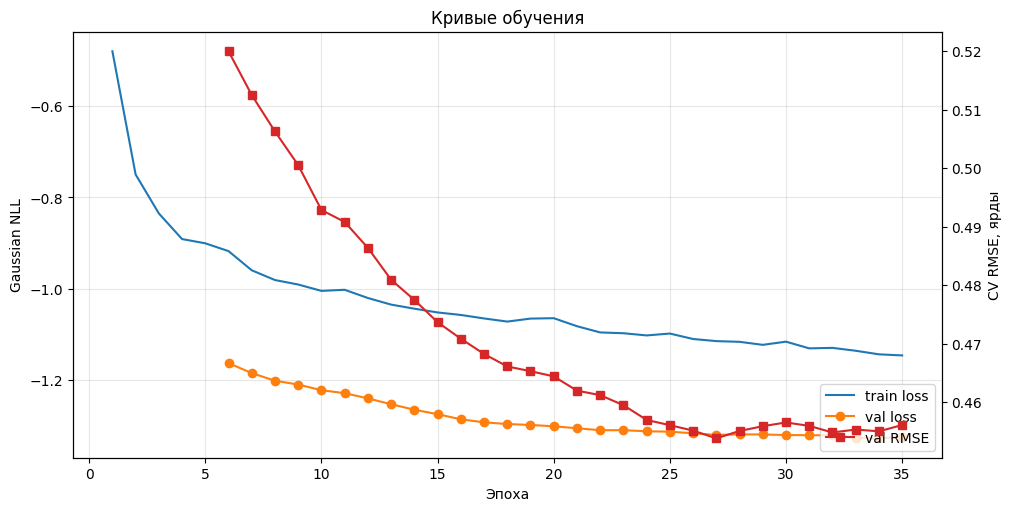

In [25]:
fig, ax1 = plt.subplots(figsize=(10, 5), constrained_layout=True)

ax1.plot(history["epoch"], history["train_loss"], label="train loss")
ax1.plot(history["epoch"], history["val_loss"], marker="o", label="val loss")
ax1.set_xlabel("Эпоха")
ax1.set_ylabel("Gaussian NLL")
ax1.grid(alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(history["epoch"], history["val_score"], color="tab:red", marker="s", label="val RMSE")
ax2.set_ylabel("CV RMSE, ярды")

l1, lab1 = ax1.get_legend_handles_labels()
l2, lab2 = ax2.get_legend_handles_labels()
ax1.legend(l1 + l2, lab1 + lab2, loc="lower right")

plt.title("Кривые обучения")
plt.savefig(RESULT_DIR / "training_curves.png", dpi=150)
plt.show()

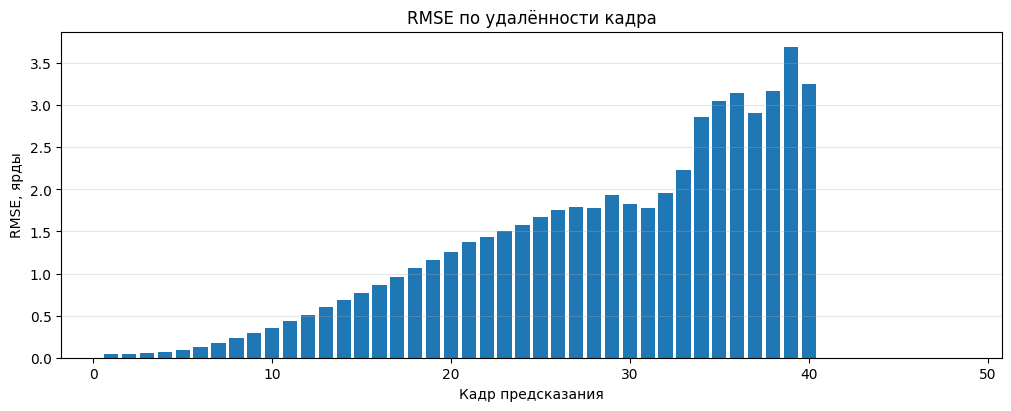

In [26]:
plt.figure(figsize=(10, 4), constrained_layout=True)
plt.bar(np.arange(1, len(frame_rmse) + 1), frame_rmse)
plt.xlabel("Кадр предсказания")
plt.ylabel("RMSE, ярды")
plt.title("RMSE по удалённости кадра")
plt.grid(alpha=0.3, axis="y")
plt.savefig(RESULT_DIR / "rmse_by_frame.png", dpi=150)
plt.show()

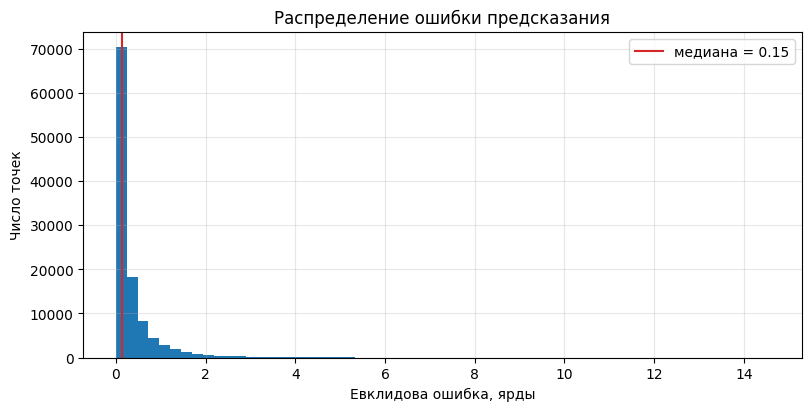

In [27]:
plt.figure(figsize=(8, 4), constrained_layout=True)
plt.hist(dist_err, bins=60)
plt.axvline(np.median(dist_err), color="tab:red", label=f"медиана = {np.median(dist_err):.2f}")
plt.xlabel("Евклидова ошибка, ярды")
plt.ylabel("Число точек")
plt.title("Распределение ошибки предсказания")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig(RESULT_DIR / "error_hist.png", dpi=150)
plt.show()

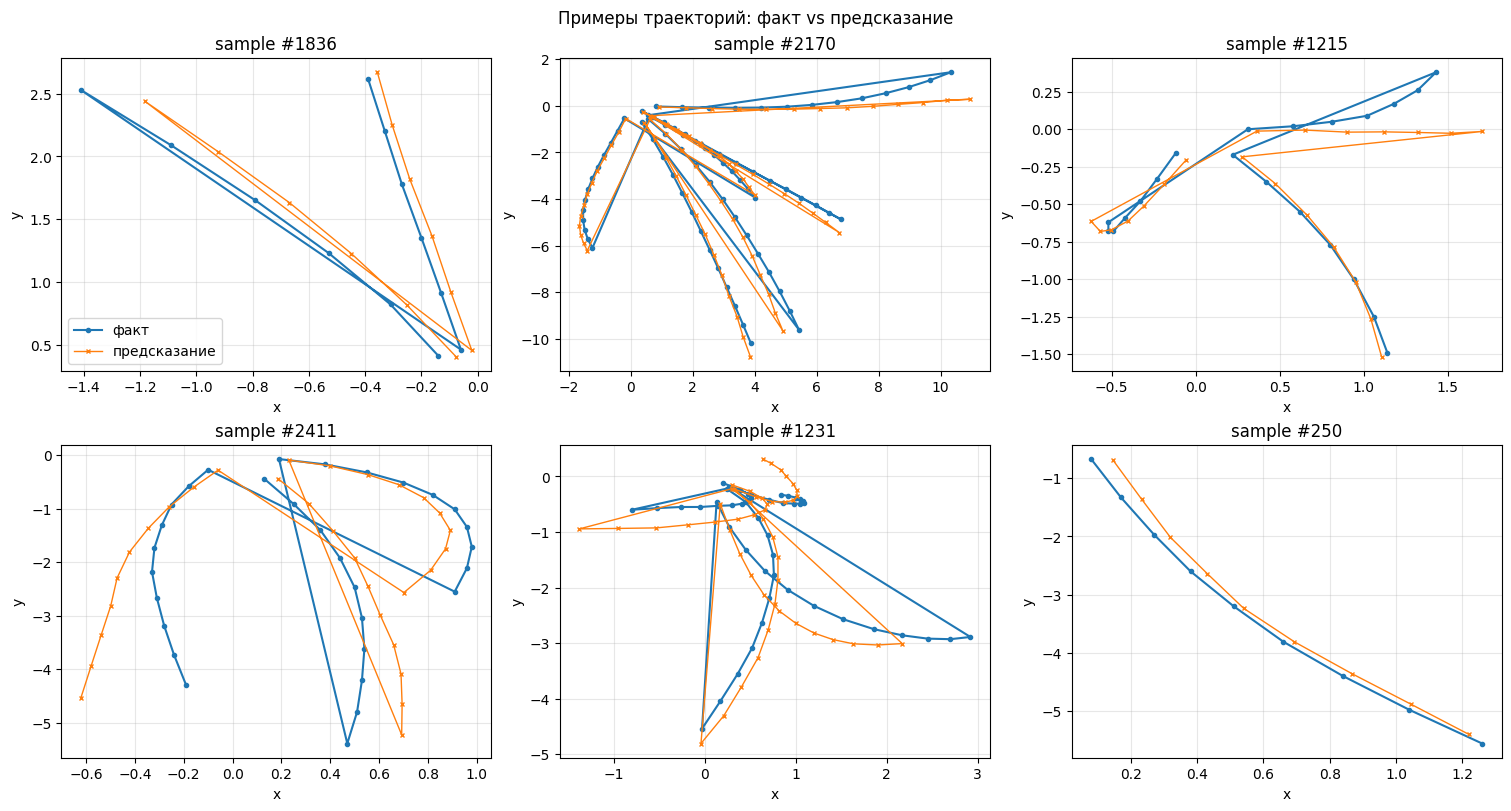

In [28]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8), constrained_layout=True)

rng = np.random.default_rng(SEED)
sample_ids = rng.choice(np.where(valid_mask.any(axis=(1, 2)))[0], size=6, replace=False)

for ax, sid in zip(axes.ravel(), sample_ids):
    m = valid_mask[sid]
    t = true_xy[sid][:, m]
    p = pred_xy[sid][:, m]
    ax.plot(t[0], t[1], marker="o", ms=3, label="факт")
    ax.plot(p[0], p[1], marker="x", ms=3, lw=1, label="предсказание")
    ax.set_title(f"sample #{sid}")
    ax.grid(alpha=0.3)
    ax.set_xlabel("x")
    ax.set_ylabel("y")

axes.ravel()[0].legend()
plt.suptitle("Примеры траекторий: факт vs предсказание")
plt.savefig(RESULT_DIR / "trajectories.png", dpi=150)
plt.show()